# Conformal Prediction Position Sizing: Two Case Studies

**Docker image**: `ml4t`

This notebook builds uncertainty-based position sizing on top of registered
walk-forward validation predictions for ETFs (`fwd_ret_21d`) and CME futures
(`fwd_ret_5d`), then
compares three allocation rules at the same top-K selection: equal weight,
conformal-width-weighted ($w_i \propto 1/\Delta_i$), and score-weighted
($w_i \propto \hat y_i$ for positive scores).

**Learning Objectives**:
- Compute per-entity Mondrian split-conformal interval widths from strictly
  prior, horizon-embargoed validation residuals
- Translate widths into position sizes via the inverse-width transform
- Compare uncertainty-weighted, score-weighted, and equal-weighted top-K
  allocations on the same prediction panel
- Identify when uncertainty-based sizing helps versus hurts

**Book Reference**: Chapter 17, Section 17.4 (Defining baseline allocators)

**Prerequisites**: `02_mean_variance_optimization`; conformal prediction from
Chapter 11 (`06_conformal_prediction`); registered GBM predictions for the
ETFs and CME futures case studies.

In [1]:
"""Compare conformal, score, and equal-weight sizing on registered GBM predictions."""

import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.metrics.ic_inference import compute_ic_hac_stats
from ml4t.diagnostic.signal.signal_ic import extract_signal_ic_series

from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, ml4t_palette, show_with_alt, zero_line

In [2]:
# Production defaults - Papermill overrides for CI testing
CONFORMAL_ALPHA = 0.20  # 80% prediction interval
TOP_K_ETF = 20  # number of ETFs in the portfolio
TOP_K_CME = 10  # number of CME products in the portfolio
HORIZON_ETF = 21  # fwd_ret_21d → 21 trading days between non-overlapping rebalances
HORIZON_CME = 5  # fwd_ret_5d  → 5 trading days
TRADING_DAYS_PER_YEAR = 252

## 1. The Conformal-to-Confidence Transform

Conformal prediction produces prediction intervals
$[\hat{y}_i - q, \hat{y}_i + q]$ where the width $2q$ reflects model uncertainty.
Here the calibration sample is strictly prior and horizon-embargoed. Narrower
intervals indicate lower historical residual dispersion for that entity and model,
which we use as a confidence proxy rather than a guarantee of future coverage.

The confidence-weighted position for entity $i$ at time $t$ within a top-$K$
selection is:

$$w_{i,t}^{conf} = \frac{1 / \Delta_{i,t}}{\sum_{j \in \text{top-}K} 1 / \Delta_{j,t}}$$

where $\Delta_{i,t}$ is the per-entity interval width. To produce cross-sectional
variation in $\Delta_i$, we use **Mondrian split-conformal calibration**:
for each fold $k$, the conformal quantile $q_i$ is computed separately for each
entity from residuals whose forward-return labels were observable before fold $k$
began. Entities with historically wider residuals get larger $\Delta_i$ and
therefore smaller weight.

## 2. Load Registered Predictions

For each case study, the GBM validation prediction set with the highest recorded IC is loaded
from its registry. During publication verification, `ML4T_OUTPUT_DIR` points to the
immutable teaching-registry overlay; readers can omit it to use their local run logs.

Both panels name their entity column `symbol`. That is a property of the prediction artifact
rather than of the case study: CME futures call the entity `product` in their labels and
features, and the training step writes the same product roots (`ES`, `CL`, `6E`, and so on)
under `symbol` when it records a prediction set.

Selection is on the validation IC recorded in the registry, so everything measured below is
conditioned on that selection and is not a holdout estimate.

In [3]:
REGISTRY_ROOTS = {
    "etfs": get_case_study_dir("etfs", create=False) / "run_log",
    "cme_futures": get_case_study_dir("cme_futures", create=False) / "run_log",
}

BEST_GBM = {
    "etfs": {"label": "fwd_ret_21d", "id_col": "symbol"},
    "cme_futures": {"label": "fwd_ret_5d", "id_col": "symbol"},
}

Registry reads are opened in SQLite read-only, immutable mode. The query excludes
prediction sets with a degenerate fold before ranking by the daily-pooled IC.

In [4]:
def resolve_best_prediction(case_study: str, label: str) -> dict[str, str | float]:
    """Resolve the top validation GBM prediction set without writing to the registry."""
    registry = REGISTRY_ROOTS[case_study] / "registry.db"
    connection = sqlite3.connect(f"file:{registry}?mode=ro&immutable=1", uri=True)
    try:
        metric_columns = {
            row[1] for row in connection.execute("PRAGMA table_info(prediction_metrics)")
        }
        ic_expr = (
            "COALESCE(pm.ic_mean_daily, pm.ic_mean)"
            if "ic_mean_daily" in metric_columns
            else "pm.ic_mean"
        )
        row = connection.execute(
            f"""
            SELECT p.prediction_hash, t.config_name, {ic_expr} AS ic_mean
            FROM training_runs t
            JOIN prediction_sets p ON t.training_hash = p.training_hash
            JOIN prediction_metrics pm ON p.prediction_hash = pm.prediction_hash
            WHERE t.family = 'gbm' AND t.label = ? AND p.split = 'validation'
              AND {ic_expr} IS NOT NULL
              AND p.prediction_hash NOT IN
                  (SELECT prediction_hash FROM fold_metrics WHERE ic IS NULL)
            ORDER BY ic_mean DESC LIMIT 1
            """,
            (label,),
        ).fetchone()
    finally:
        connection.close()
    if row is None:
        raise RuntimeError(f"No eligible GBM validation predictions for {case_study}/{label}")
    return {"prediction_hash": row[0], "config_name": row[1], "ic_mean": float(row[2])}

In [5]:
for _case_study, _config in BEST_GBM.items():
    _best = resolve_best_prediction(_case_study, _config["label"])
    _config.update(_best)
    print(
        f"{_case_study}: validation GBM {_best['config_name']} "
        f"({_best['prediction_hash']}), selection IC={_best['ic_mean']:.4f}"
    )

etfs: validation GBM leaves_7_huber (3e9ab3c5914b), selection IC=0.0547
cme_futures: validation GBM default_mae (667fee69304f), selection IC=0.0214


In [6]:
def load_predictions(case_study: str) -> pl.DataFrame:
    """Load one canonical validation prediction panel and reject malformed keys."""
    cfg = BEST_GBM[case_study]
    path = (
        REGISTRY_ROOTS[case_study] / "predictions" / cfg["prediction_hash"] / "predictions.parquet"
    )
    df = pl.read_parquet(path)
    id_col = cfg["id_col"]
    required = ["timestamp", id_col, "fold", "prediction", "actual"]
    missing = set(required) - set(df.columns)
    if missing or df.select(required).null_count().sum_horizontal().item() > 0:
        raise ValueError(f"Malformed {case_study} prediction panel: missing={sorted(missing)}")
    if df.select(id_col, "timestamp", "fold").is_duplicated().any():
        raise ValueError(f"Duplicate canonical keys in {case_study} prediction panel")
    return df.select(required)

In [7]:
preds = {cs: load_predictions(cs) for cs in REGISTRY_ROOTS}
for cs, df in preds.items():
    cfg = BEST_GBM[cs]
    print(
        f"{cs}: {df.height:,} rows, {df[cfg['id_col']].n_unique()} entities, "
        f"{df['fold'].n_unique()} validation folds, "
        # strftime, not .date(): a prediction artifact's timestamp is Date in some case
        # studies and Datetime in others - etfs ships both - and `datetime.date` has no
        # .date(). Both types format the same way.
        f"{df['timestamp'].min():%Y-%m-%d} to {df['timestamp'].max():%Y-%m-%d}"
    )

etfs: 188,473 rows, 99 entities, 8 validation folds, 2015-12-28 to 2023-11-29
cme_futures: 38,262 rows, 30 entities, 5 validation folds, 2019-01-03 to 2023-12-21


## 3. Signal Strength of the Underlying GBM Predictions

Conformal position sizing only adds value when the underlying signal has
meaningful cross-sectional predictive power. If IC is near zero, weighting
*anything* by inverse uncertainty cannot rescue the strategy - the
conformal widths just rescale noise.

We summarize daily cross-sectional Spearman IC and use Newey-West inference
with at least $h-1$ lags. That horizon-aware correction matters because daily
IC observations share overlapping 5-day or 21-day forward returns. These are
descriptive diagnostics on the same validation panel used to select the GBM,
so they do not establish an unbiased out-of-sample edge.

In [8]:
ic_summaries = {}
for cs, df in preds.items():
    id_col = BEST_GBM[cs]["id_col"]
    horizon = HORIZON_ETF if cs == "etfs" else HORIZON_CME
    sig_df = df.rename(
        {
            "prediction": "factor",
            "actual": f"{horizon}D_fwd_return",
        }
    ).select(["timestamp", id_col, "factor", f"{horizon}D_fwd_return"])
    _, ic_values = extract_signal_ic_series(
        sig_df,
        period=horizon,
        date_col="timestamp",
        asset_col=id_col,
    )
    hac = compute_ic_hac_stats(np.asarray(ic_values), label_horizon=horizon)
    ic_summaries[cs] = {
        "mean": hac["mean_ic"],
        "t_stat": hac["t_stat"],
        "p_value": hac["p_value"],
        "pct_positive": float(np.mean(np.asarray(ic_values) > 0)),
        "effective_lags": hac["effective_lags"],
        "horizon": horizon,
        "n_dates": len(ic_values),
    }

for cs, s in ic_summaries.items():
    print(
        f"{cs}: mean IC={s['mean']:+.4f}, HAC t={s['t_stat']:+.2f} "
        f"(lags={s['effective_lags']}), positive on {s['pct_positive']:.1%} "
        f"of {s['n_dates']:,} validation dates"
    )

etfs: mean IC=+0.0547, HAC t=+2.61 (lags=20), positive on 58.7% of 1,995 validation dates
cme_futures: mean IC=+0.0214, HAC t=+1.45 (lags=7), positive on 53.3% of 1,285 validation dates


Mean IC and the share of positive dates describe whether the selected signal
ranks returns at all; the HAC statistic prevents overlapping labels from
manufacturing precision. The result remains selection-conditioned validation
evidence. The next section asks a separate question: whether residual widths
vary enough across entities for inverse-width sizing to differ from equal weight.

## 4. Per-Entity Mondrian Widths Without Future-Fold Calibration

For each fold $k$ and entity $i$, we compute the conformal order statistic from
absolute residuals on chronologically prior folds. We also remove the trailing
$h$ timestamps whose labels would not yet be observable when fold $k$ begins.
The width applied to fold-$k$ predictions is

$$\Delta_{i,k} = 2 \cdot r_{(\lceil(n+1)(1-\alpha)\rceil)},$$

where $r_{(j)}$ is the $j$th ordered residual and the rank is capped at $n$.
The earliest fold has no valid prior calibration pool and is excluded rather
than borrowing future residuals. Consequently, all evaluated folds obey the
same walk-forward contract.

Per-entity calibration produces the cross-sectional width variation that
drives $1/\Delta_i$ weighting. Pooled calibration
split conformal would produce a single width per fold, collapsing the
conformal weights to equal weights.

The finite-sample rank uses the standard split-conformal $(n+1)$ correction.
This small helper is also exercised against a hand-calculated oracle before execution.

In [9]:
def conformal_order_stat(residuals: np.ndarray, alpha: float) -> float:
    """Return the finite-sample split-conformal residual order statistic."""
    ordered = np.sort(np.asarray(residuals, dtype=float))
    if ordered.size == 0:
        raise ValueError("Conformal calibration requires at least one residual")
    rank = min(int(np.ceil((ordered.size + 1) * (1.0 - alpha))), ordered.size)
    return float(ordered[rank - 1])

Fold order is derived from timestamps rather than numeric fold IDs. A residual
enters fold $k$'s calibration pool only when its origin plus the label horizon
is strictly earlier than fold $k$'s first timestamp.

In [10]:
def mondrian_widths(df: pl.DataFrame, id_col: str, horizon: int, alpha: float) -> pl.DataFrame:
    """Compute strictly prior, horizon-embargoed widths for each evaluable fold."""
    calendar = df.select("timestamp").unique().sort("timestamp").with_row_index("time_index")
    panel = df.join(calendar, on="timestamp").with_columns(
        abs_resid=(pl.col("actual") - pl.col("prediction")).abs()
    )
    fold_starts = (
        panel.group_by("fold").agg(start_index=pl.col("time_index").min()).sort("start_index")
    )

    rows: list[dict[str, str | int | float]] = []
    for fold, start_index in fold_starts.iter_rows():
        if start_index == fold_starts["start_index"].min():
            continue
        current_ids = panel.filter(pl.col("fold") == fold)[id_col].unique()
        calibration = panel.filter(
            (pl.col("time_index") + horizon < start_index)
            & pl.col(id_col).is_in(current_ids.to_list())
        )
        for entity_key, group in calibration.group_by(id_col):
            entity = entity_key[0]
            quantile = conformal_order_stat(group["abs_resid"].to_numpy(), alpha)
            if quantile <= 0:
                raise ValueError(f"Non-positive conformal width for {entity}, fold {fold}")
            rows.append(
                {
                    id_col: entity,
                    "fold": int(fold),
                    "width": 2.0 * quantile,
                    "n_calibration": group.height,
                }
            )
    return pl.DataFrame(rows)

In [11]:
widths = {}
for cs, df in preds.items():
    config = BEST_GBM[cs]
    horizon = HORIZON_ETF if cs == "etfs" else HORIZON_CME
    widths[cs] = mondrian_widths(df, config["id_col"], horizon, CONFORMAL_ALPHA)

for cs, w in widths.items():
    print(
        f"{cs}: {w.height} entity-fold widths across {w['fold'].n_unique()} evaluable folds; "
        f"median={w['width'].median():.4f}, range={w['width'].min():.4f} to "
        f"{w['width'].max():.4f}"
    )

etfs: 665 entity-fold widths across 7 evaluable folds; median=0.0992, range=0.0110 to 0.4157
cme_futures: 120 entity-fold widths across 4 evaluable folds; median=0.0623, range=0.0038 to 0.2060


Because the two labels have different horizons, raw widths are not directly
comparable. Normalizing each width by its case-study median isolates relative
cross-sectional dispersion, the quantity that makes inverse-width weights depart
from equal weight.

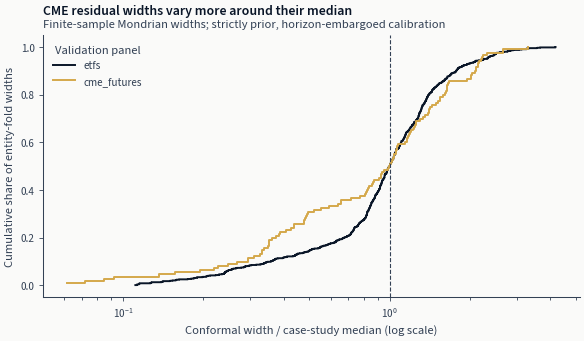

In [12]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for (cs, w), color in zip(widths.items(), ml4t_palette(2, categorical=True), strict=True):
    relative_width = np.sort(w["width"].to_numpy() / w["width"].median())
    cumulative_share = np.arange(1, relative_width.size + 1) / relative_width.size
    ax.step(relative_width, cumulative_share, where="post", label=cs, color=color)

ax.axvline(1.0, color=COLORS["neutral"], linewidth=0.8, linestyle="--")
ax.set_xscale("log")
ax.set_xlabel("Conformal width / case-study median (log scale)")
ax.set_ylabel("Cumulative share of entity-fold widths")
ax.legend(title="Validation panel")
add_message_title(
    ax,
    "CME residual widths vary more around their median",
    subtitle="Finite-sample Mondrian widths; strictly prior, horizon-embargoed calibration",
)
show_with_alt(
    fig,
    "Two step curves of the cumulative share of entity-fold conformal widths against width divided by the case study's own median, on a logarithmic horizontal axis, with a dashed line at the median. The CME curve is the flatter of the two.",
)

## 5. Allocation Rules

At each timestamp $t$ we (a) select the top-$K$ entities by signed
$\hat y_{i,t}$, restricted to rows whose prediction is positive (long-only
return-score allocation), then (b) form weights using each rule:

- **Equal weight**: $w_i = 1/K$.
- **Conformal-weighted**: $w_i = (1/\Delta_{i,t}) / \sum_{j \in \text{top-}K}(1/\Delta_{j,t})$.
- **Score-weighted**: $w_i = \hat y_{i,t} / \sum_{j \in \text{top-}K}\hat y_{j,t}$.

All weights are non-negative and sum to one - long-only by construction. The
realized portfolio return at $t$ is $r_t = \sum_i w_{i,t}\,y_{i,t}$, where
$y_{i,t}$ is the realized forward return label aligned to the prediction
timestamp (`actual` column in the parquet). If fewer than $K$ entities have
a positive predicted return at $t$, the selection drops to that smaller
size; if none are positive the timestamp is skipped.

A single global schedule is built after the uncalibrated first fold is removed.
It never resets at fold boundaries, so adjacent folds cannot reintroduce
overlapping forward-return windows.

In [13]:
def nonoverlap_schedule(df: pl.DataFrame, horizon: int) -> pl.DataFrame:
    """Select every horizon-th timestamp once across the full evaluation panel."""
    return (
        df.select("timestamp")
        .unique()
        .sort("timestamp")
        .with_row_index("time_index")
        .filter(pl.col("time_index") % horizon == 0)
        .select("timestamp")
    )

The three allocators share the same positive-score top-$K$ selection. Only the
within-selection weights differ, which isolates the sizing decision.

In [14]:
def build_portfolio_returns(
    df: pl.DataFrame,
    widths: pl.DataFrame,
    id_col: str,
    top_k: int,
    horizon: int,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Build non-overlapping validation returns and native-identifier weights."""
    panel = df.join(
        widths.select(id_col, "fold", "width"), on=[id_col, "fold"], how="inner"
    ).drop_nulls(subset=["prediction", "actual", "width"])
    panel = panel.join(nonoverlap_schedule(panel, horizon), on="timestamp", how="inner")
    panel = panel.filter(pl.col("prediction") > 0).with_columns(
        rank=pl.col("prediction").rank(method="ordinal", descending=True).over("timestamp")
    )
    top = panel.filter(pl.col("rank") <= top_k)

    inv_w = 1.0 / pl.col("width")
    score = pl.col("prediction")

    top = top.with_columns(
        w_ew=pl.lit(1.0) / pl.len().over("timestamp"),
        w_conf=inv_w / inv_w.sum().over("timestamp"),
        w_score=score / score.sum().over("timestamp"),
    )

    realized = (
        top.group_by("timestamp")
        .agg(
            ret_ew=(pl.col("w_ew") * pl.col("actual")).sum(),
            ret_conf=(pl.col("w_conf") * pl.col("actual")).sum(),
            ret_score=(pl.col("w_score") * pl.col("actual")).sum(),
        )
        .sort("timestamp")
    )
    weights_long = top.select("timestamp", id_col, "w_ew", "w_conf", "w_score").sort(
        "timestamp", id_col
    )
    return realized, weights_long

One-way turnover is half the $L_1$ change in weights. The factor of one-half
avoids counting every sale and offsetting purchase as two separate reallocations.

In [15]:
def compute_turnover(weights_long: pl.DataFrame, id_col: str, weight_col: str) -> float:
    """Return mean one-way turnover across consecutive rebalances."""
    w = weights_long.pivot(
        index="timestamp", on=id_col, values=weight_col, aggregate_function="first"
    ).fill_null(0.0)
    arr = w.drop("timestamp").to_numpy()
    if arr.shape[0] < 2:
        return float("nan")
    return float(0.5 * np.mean(np.abs(np.diff(arr, axis=0)).sum(axis=1)))

Sharpe and Sortino scale by the number of non-overlapping horizon periods per
year. Annual return comes from the realized compounded path, not by compounding
the arithmetic mean return.

In [16]:
def metric_block(
    rets: pl.DataFrame, weights: pl.DataFrame, id_col: str, horizon: int
) -> dict[str, dict[str, float]]:
    """Compute path-consistent validation metrics for the three allocators."""
    periods_per_year = TRADING_DAYS_PER_YEAR / horizon
    ann_sqrt = np.sqrt(periods_per_year)

    out: dict[str, dict[str, float]] = {}
    for name, ret_col, w_col in [
        ("baseline_equal_weight", "ret_ew", "w_ew"),
        ("conformal_weighted", "ret_conf", "w_conf"),
        ("score_weighted", "ret_score", "w_score"),
    ]:
        r = rets[ret_col].to_numpy()
        mu = r.mean()
        sd = r.std(ddof=1)
        _downside_raw = float(np.sqrt(np.mean(np.minimum(r, 0.0) ** 2)))
        downside = _downside_raw if _downside_raw > 0 else np.nan
        cum = np.cumprod(1.0 + r)
        peak = np.maximum.accumulate(cum)
        max_dd = float((cum / peak - 1.0).min())
        annual_return = (
            float(cum[-1] ** (periods_per_year / r.size) - 1.0)
            if r.size > 0 and np.all(1.0 + r > 0)
            else float("nan")
        )
        out[name] = {
            "sharpe": float(mu / sd * ann_sqrt) if sd > 0 else float("nan"),
            "sortino": float(mu / downside * ann_sqrt)
            if downside == downside and downside > 0
            else float("nan"),
            "max_drawdown": max_dd,
            "win_rate": float((r > 0).mean()),
            "avg_turnover": compute_turnover(weights, id_col, w_col),
            "n_obs": int(r.shape[0]),
            "ann_return": annual_return,
        }
    return out

**On rebalancing and annualization.** The prediction panel is daily but each
row's `actual` is a forward 5-day or 21-day return. To avoid the overlap that
would inflate Sharpe and break drawdown accounting, one global schedule keeps
every `HORIZON`th trading date without restarting at fold boundaries. The
Sharpe is annualized by $\sqrt{252/h}$ - for ETFs with $h=21$ this is
$\sqrt{12}$; for CME with $h=5$ this is $\sqrt{50.4}$. The realized portfolio
return at each rebalance date $t$ is $\sum_i w_{i,t}\,y_{i,t}$, where $y_{i,t}$
is the $h$-day forward return and the cohort is held to maturity (no
intra-period rebalancing).

## 6. ETFs (`fwd_ret_21d`)

The first validation fold is excluded because it has no strictly prior
calibration residuals. The remaining folds share one global 21-session
rebalance schedule. These metrics compare allocators on the selected GBM's
validation panel; they are not final holdout performance.

In [17]:
etf_rets, etf_weights = build_portfolio_returns(
    preds["etfs"], widths["etfs"], "symbol", TOP_K_ETF, HORIZON_ETF
)
etf_metrics = metric_block(etf_rets, etf_weights, "symbol", HORIZON_ETF)
print(f"ETFs: {etf_rets.height} non-overlapping validation rebalances")

ETFs: 75 non-overlapping validation rebalances


In [18]:
for label, key in [
    ("Equal Weight", "baseline_equal_weight"),
    ("Conformal Weighted", "conformal_weighted"),
    ("Score Weighted", "score_weighted"),
]:
    m = etf_metrics[key]
    print(
        f"{label}: Sharpe {m['sharpe']:.3f}, annual return {m['ann_return']:.1%}, "
        f"max drawdown {m['max_drawdown']:.1%}, one-way turnover {m['avg_turnover']:.3f}"
    )

Equal Weight: Sharpe 0.541, annual return 8.6%, max drawdown -25.3%, one-way turnover 0.384
Conformal Weighted: Sharpe 0.568, annual return 9.0%, max drawdown -23.2%, one-way turnover 0.425
Score Weighted: Sharpe 0.499, annual return 7.8%, max drawdown -25.3%, one-way turnover 0.392


## 7. CME Futures (`fwd_ret_5d`)

The same protocol excludes the first fold and uses a global five-session
schedule across the rest. The entity values are CME product roots; the
prediction artifact stores them under `symbol`, as it does for every case
study.

In [19]:
cme_rets, cme_weights = build_portfolio_returns(
    preds["cme_futures"], widths["cme_futures"], "symbol", TOP_K_CME, HORIZON_CME
)
cme_metrics = metric_block(cme_rets, cme_weights, "symbol", HORIZON_CME)
print(f"CME futures: {cme_rets.height} non-overlapping validation rebalances")

CME futures: 206 non-overlapping validation rebalances


In [20]:
for label, key in [
    ("Equal Weight", "baseline_equal_weight"),
    ("Conformal Weighted", "conformal_weighted"),
    ("Score Weighted", "score_weighted"),
]:
    m = cme_metrics[key]
    print(
        f"{label}: Sharpe {m['sharpe']:.3f}, annual return {m['ann_return']:.1%}, "
        f"max drawdown {m['max_drawdown']:.1%}, one-way turnover {m['avg_turnover']:.3f}"
    )

Equal Weight: Sharpe 0.503, annual return 8.0%, max drawdown -35.8%, one-way turnover 0.417
Conformal Weighted: Sharpe 0.359, annual return 4.5%, max drawdown -32.6%, one-way turnover 0.516
Score Weighted: Sharpe 0.540, annual return 13.5%, max drawdown -40.3%, one-way turnover 0.470


## 8. Allocation Trade-offs on Validation

Each panel uses the same case-study axis and allocator colors. Sharpe and
annual return measure reward, max drawdown measures path risk, and one-way
turnover shows how aggressively each sizing rule changes positions.

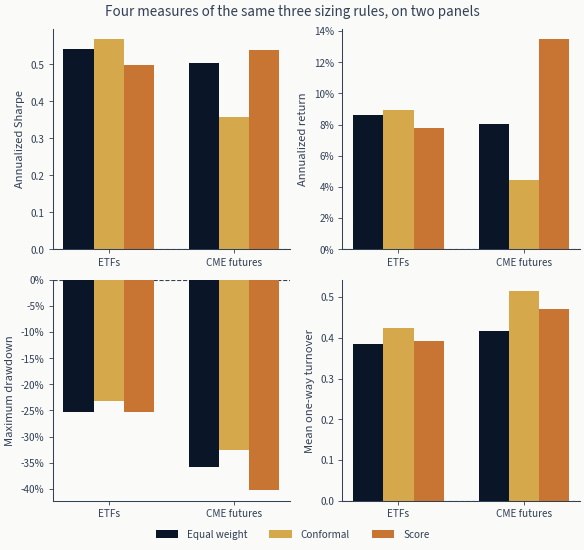

In [21]:
case_metrics = {"ETFs": etf_metrics, "CME futures": cme_metrics}
method_keys = ["baseline_equal_weight", "conformal_weighted", "score_weighted"]
method_labels = ["Equal weight", "Conformal", "Score"]
metric_specs = [
    ("sharpe", "Annualized Sharpe"),
    ("ann_return", "Annualized return"),
    ("max_drawdown", "Maximum drawdown"),
    ("avg_turnover", "Mean one-way turnover"),
]

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE["dashboard_2x2"])
x = np.arange(len(case_metrics))
bar_width = 0.24
colors = ml4t_palette(3, categorical=True)
legend_handles = []
for panel_index, (ax, (metric, label)) in enumerate(zip(axes.flat, metric_specs, strict=True)):
    for offset, (method, method_label, color) in enumerate(
        zip(method_keys, method_labels, colors, strict=True)
    ):
        values = [metrics[method][metric] for metrics in case_metrics.values()]
        bars = ax.bar(
            x + (offset - 1) * bar_width, values, bar_width, label=method_label, color=color
        )
        if panel_index == 0:
            legend_handles.append(bars)
    zero_line(ax)
    ax.set_xticks(x, case_metrics.keys())
    ax.set_ylabel(label)
    if metric in {"ann_return", "max_drawdown"}:
        ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

fig.suptitle("Four measures of the same three sizing rules, on two panels")
fig.legend(legend_handles, method_labels, loc="outside lower center", ncol=3)
show_with_alt(
    fig,
    "Four panels comparing equal-weight, conformal and score-weighted sizing on the ETF and CME panels: annualized Sharpe, annualized return, maximum drawdown and mean one-way turnover, three grouped bars per case study in each panel.",
)

### What this run produced

Two panels, three sizing rules, four measures each - all printed in sections 6 and 7 and drawn
together in the four-panel figure. The three rules share one selection at every rebalance, so
any difference between them comes from the weights alone.

Read the Sharpe panel against the turnover panel rather than on its own. A sizing rule that
improves Sharpe while turning over more has not been shown to be worth using: this comparison
is gross of the cost of that turnover, and Chapter 18 measures what it would take out. The two
case studies also differ in how strong the underlying signal is, which section 3 reports as a
HAC t-statistic on the mean IC - a sizing rule applied to a signal that does not rank returns
is rescaling noise, whatever its Sharpe ratio comes out at.

## Key Takeaways

1. **Per-entity calibration creates the sizing signal.** Pooled calibration
   would produce one width per fold and collapse inverse-width sizing to equal
   weight. The finite-sample Mondrian widths use only prior residuals whose
   labels are available before the next fold; the uncalibrated first fold is
   excluded rather than filled from the future.

2. **Inverse-width sizing is a bet on the residual dispersion being stable.** It puts more
   capital where the model's past residuals were narrow. That helps only if an entity whose
   residuals were narrow in the calibration window stays that way in the evaluation window;
   nothing in conformal prediction guarantees it, and the printed comparison is what says
   whether it held here.

3. **Width dispersion is necessary but not sufficient.** Inverse-width weights depart from
   equal weight only in proportion to how much the widths differ across entities, so a panel
   with tight dispersion cannot produce a materially different portfolio. Dispersion is what
   makes the rule able to act; it is not what makes the action pay. Uncertainty changes
   position size and cannot manufacture predictive direction.

4. **Treat these results as validation diagnostics.** The GBM was selected by
   validation IC from the same registry panel. A holdout that no selection step has seen is
   required before any allocator ranking counts as out-of-sample evidence.

**Next**: [`08_library_comparison`](08_library_comparison.ipynb) puts four allocation
libraries on the same problem and compares what each one produces.

**Book**: Section 17.4 lists conformal-weighted allocation alongside the
inverse-volatility, score-weighted, and equal-weight baselines.